In [1]:
%matplotlib inline

# lkprf aperture tutorial

## Author
Rebekah Hounsell- TESS Science Support Center

## Tutorial Goals

This tutorial is a follow on from the lkprf TPF example tutorial. It demostrates how a user can calculate an aperture for an object of interest using knowledge of its PRF. 

There are three kinds of aperture that we will implement:

- Simple: This computes that aperture that covers the total light of the targets PRF. This is a very simple aperture which should only be used for bright isolated stare. The user determines the level of target flux to be included within the aperture using a completeness metric.
- Strict: This aperture is calculated using a measurement of the target flux / flux from all other contaminating sources. In this method the PRF is computed for the target and for other contaminating stars within the surronding region. The cumulative signal to noise is then calculated for the target and the local minima derived. This is then used to compute the size of the aperture mask.
- Crowded: This aperture is calculated based on the level of crowding acceptable to the user and the level of flux to be excluded. It has two input parameters, the flux fraction and the crowding fraction.

An example of all three apertures are shown below for both a bright source, AU Mic, and a faint crowded source TIC 120916706.

In [15]:
import matplotlib.pyplot as plt
import lkprf
import lkprf.aperture as aper
from lksearch.catalogsearch import query_region
import numpy as np
from astropy.wcs import WCS
from astropy.io import fits
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord

## Step 1: Get a the TPF
We will start by getting the Target Pixel File for a relatively isolated (low contamination) star, AU Mic. We limit the search using pipeline='SPOC', which restricts the search results to files produced by the mission pipeline. 

In [3]:
tpf_bright_search = lksearch.TESSSearch('Au Mic', pipeline='SPOC').cubedata
tpf_bright_search

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,441420236,SPOC,TESS,1,120.0,0.0,2018,Target pixel files
1,441420236,SPOC,TESS,27,20.0,0.0,2020,Target pixel files
2,441420236,SPOC,TESS,27,120.0,0.0,2020,Target pixel files


The search result contains a table showing all of the observations of the target for which SPOC data is available to download. The exptime column indicates the observing cadence by TESS. 

As we know from the previous tutorials the TPF will be different for this target for every observing sector, as the target will fall on different pixels and different camera and CCDs. Let's just pick a single sector to model. In the download command below, we specify the 1st element of the table, corresponding to the 20-second cadence TPF from sector 27.

In [5]:
tpf_bright = tpf_bright_search[1].download()
tpf_bright

,Local Path,Status,Message,URL
0,/Users/rhounsel/.lksearch/cache/mastDownload/T...,COMPLETE,None,None


We now have our dataframe containing the local file path it is downloaded to.  However, it does not read it in to a lightkurve object. We will read it in using the fits file handling package in astropy. If you need a refresher on fits file handling, you can see this [astropy tutorial](https://learn.astropy.org/tutorials/FITS-images.html). 

In [6]:
tess_hdulist = fits.open(tpf_bright['Local Path'].values[0])

## Step 2: Create a PRF model

Now that we have our file, we can set up our PRF model. 
To initiate a PRF object, we need to know which camera and CCD (TESS) or channel (Kepler) the target is on. We also can optionally provide the observing Sector for TESS. This is because two sets of PRF engineering models were produced for TESS. The first models were made during commissioning and are used for the early Sectors (Sectors 1-3). The commissioning observations were re-run after Sector 3, and these files can be used for subsequent TESS sectors. If the sector is not specified, the models produced for Sectors 4 onwards are used.

In [17]:
camera = tess_hdulist[0].header['CAMERA']
ccd = tess_hdulist[0].header['CCD']
sector = tess_hdulist[0].header['SECTOR'] 

# initialize the PRF object
prf_initial = lkprf.TESSPRF(camera=camera, ccd=ccd, sector=sector) 

# get the WCS information
wcs = WCS(tess_hdulist[2].header)

# get the shape of our object
shape = tess_hdulist[1].data['FLUX'].shape[1:]


Now we want to assess what other objects might be in the surronding field. We can do this using lksearch and some information from the header of our object. We specify the number of targets to collect information for via the max_results input. 

In [16]:
ra = tess_hdulist[0].header['RA_OBJ'] 
dec = tess_hdulist[0].header['DEC_OBJ'] 

radius = np.round(max(shape)/2) * 21 * u.arcsec

surronding_objects = query_region(SkyCoord(ra=ra, dec=dec, unit='deg'), output_epoch=Time.now(), catalog="tic", radius=radius, max_results=15)

We then want to filter our results and remove any objects that might have a 'nan' for the RA. From the resultant dataframe we can get the Tess Magnitude for our object and the surronding objects in addition to the RA and Dec's of our objects.

In [18]:
df_cleaned = surronding_objects.dropna(subset=['RA']).reset_index(drop=True)

TESS_mags = df_cleaned['TESSmag'].values
surronding_objects_ra = df_cleaned['RA'].values
surronding_objects_dec = df_cleaned['Dec'].values

We can then convert these values into pixels within our prf model using the wcs. 

In [19]:
column, row = wcs.world_to_pixel(SkyCoord(surronding_objects_ra,surronding_objects_dec, unit="deg"))

origin_row =  tess_hdulist[1].header['2CRV4P'] 
origin_col =  tess_hdulist[1].header['1CRV4P'] 

target_col = column + origin_col 
target_row = row + origin_row

target_list = list(zip(target_row, target_col))

These can then be used to create our 3D PRF model.

In [20]:
prf_mod = prf_initial.evaluate(targets=target_list,origin=(origin_row,origin_col),shape=shape)

We now have a model PRF's for our object and 14 other objects in the field that can be contaminating our source. Lets plot the target and its PRF model.

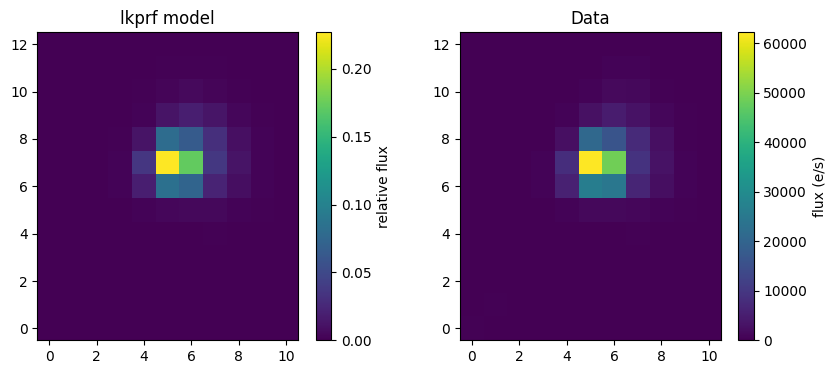

In [22]:
fig,axs = plt.subplots(1,2,figsize=(10,4))

model = axs[0].imshow(prf_mod[0,:,:], origin='lower')
axs[0].set_title('lkprf model')
fig.colorbar(model, ax = axs[0], label='relative flux')

# Plot the real data. We randomly select the 100th observation from the TPF data cube
data = axs[1].imshow(tess_hdulist[1].data['FLUX'][100,:,:],  origin='lower')
axs[1].set_title('Data')
fig.colorbar(data, ax = axs[1], label = 'flux (e/s)')

plt.show()


Now lets calculate all possible apertures for our object and see what is selected. 

In [53]:
myap = aper(model_prf=prf_mod,tess_mag=TESS_mags,target_index=0)
simple_ap = myap.simple_aperture(completeness=0.99)
strict_ap = myap.strict_aperture()
crowded_ap = myap.crowded_aperture(crowding_metric = 0.8, fluxfrac_metric = 0.9)

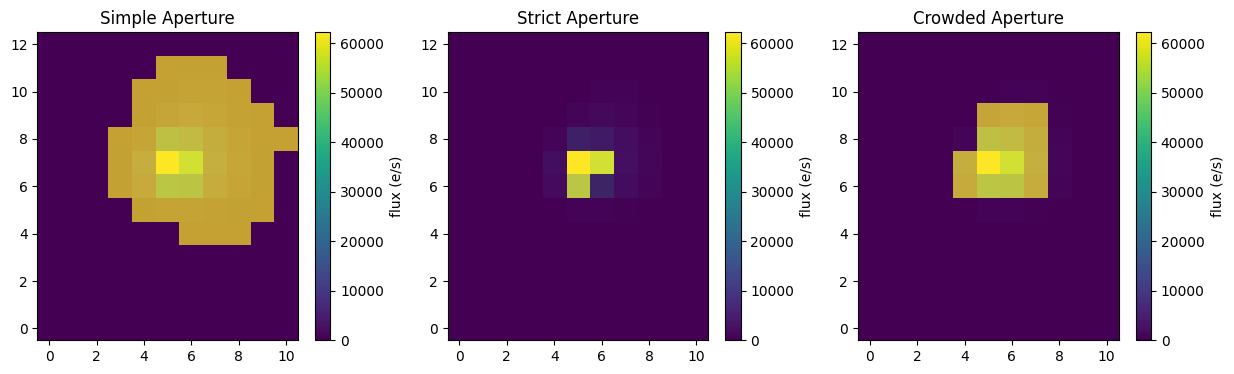

In [59]:
fig,axs = plt.subplots(1,3,figsize=(15,4))

data = axs[0].imshow(tess_hdulist[1].data['FLUX'][100,:,:],  origin='lower')
axs[0].imshow(simple_ap, alpha=0.7, origin='lower')
axs[0].set_title('Simple Aperture')
fig.colorbar(data, ax = axs[0], label = 'flux (e/s)')

data = axs[1].imshow(tess_hdulist[1].data['FLUX'][100,:,:],  origin='lower')
axs[1].imshow(strict_ap, alpha=0.7, origin='lower')
axs[1].set_title('Strict Aperture')
fig.colorbar(data, ax = axs[1], label = 'flux (e/s)')

data = axs[2].imshow(tess_hdulist[1].data['FLUX'][100,:,:],  origin='lower')
axs[2].imshow(crowded_ap, alpha=0.7,origin='lower')
axs[2].set_title('Crowded Aperture')
fig.colorbar(data, ax = axs[2], label = 'flux (e/s)')

plt.show()

As we can see the simple aperture with 99% completeness is quite large, the strict aperture is quite small and will contain the maximum amount of flux from our target with the lest amount of contamination. The final crowded aperture tries to get 90% of the target flux while only allowing 20% contamination from surronding stars. 

Now lets repeat the experiment with a much fainter object, TIC 120916706.

In [60]:
tpf_faint_search = lksearch.TESSSearch("TIC 120916706", pipeline='SPOC').cubedata
tpf_faint_search

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,120916706,SPOC,TESS,3,120.0,0.0,2018,Target pixel files
1,120916706,SPOC,TESS,30,120.0,0.0,2020,Target pixel files


In [61]:
tpf_faint = tpf_faint_search[0].download()

In [62]:
tess_hdulist_faint = fits.open(tpf_faint['Local Path'].values[0])

Let's plot this up and see what the target and its surronding region looks like.

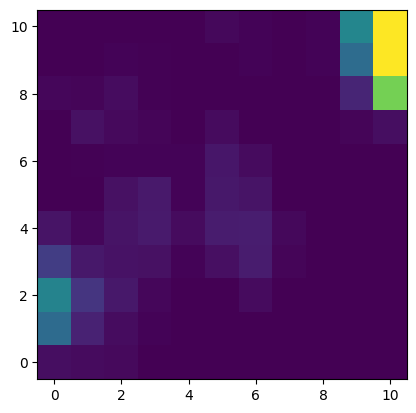

In [72]:
plt.imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:], vmin=5, vmax=200, origin='lower')

Our object is in the center of the field and is very faint and surronded by lots of other faint and bright objects. To calculate an aperture we must take these objects into accont. We do this following the method above. First get the primary data information.

In [75]:
camera_faint = tess_hdulist_faint[0].header['CAMERA']
ccd_faint = tess_hdulist_faint[0].header['CCD']
sector_faint = tess_hdulist_faint[0].header['SECTOR'] 

# initialize the PRF object
prf_initial_faint = lkprf.TESSPRF(camera=camera_faint, ccd=ccd_faint, sector=sector_faint) 

# get the WCS information
wcs_faint = WCS(tess_hdulist_faint[2].header)

# get the shape of our object
shape_faint = tess_hdulist_faint[1].data['FLUX'].shape[1:]

Now examine objects within the surronding region.

In [90]:
ra_faint = tess_hdulist_faint[0].header['RA_OBJ'] 
dec_faint = tess_hdulist_faint[0].header['DEC_OBJ'] 

radius_faint = np.round(max(shape_faint)/2) * 21 * u.arcsec

surronding_objects_faint = query_region(SkyCoord(ra=ra_faint, dec=dec_faint, unit='deg'), output_epoch=Time.now(), catalog="tic", radius=radius_faint, max_results=10)

surronding_objects_faint

,ID,RA,Dec,Separation,Relative_Flux,pmRA,pmDE,TESSmag,Mass,Rad,Teff,logg
0,TIC 120916706,37.108371,-25.097300,0.000000,1.000000,30.333,10.142,15.620000,0.436,0.440,3423.0,4.7907
1,TIC 120916709,37.097679,-25.087633,49.256425,1.221237,-0.417,8.098,15.403000,0.760,0.652,4721.0,4.6905
2,TIC 120916710,37.114387,-25.083546,53.257511,1.088429,8.141,-1.314,15.528000,1.000,0.979,5625.0,4.4562
3,TIC 120916705,37.130259,-25.101787,73.161995,0.281838,6.393,-5.949,16.995001,0.650,0.961,4130.0,4.2859
4,TIC 120916707,37.135356,-25.091443,90.468461,0.976338,62.346,-1.405,15.646000,1.030,0.577,5741.0,4.9287
5,TIC 120916704,37.124029,-25.119028,93.401087,0.561823,5.918,-5.036,16.246000,0.720,0.823,4567.0,4.4645


There are lots of similarly bright objects in this region, we must model these.

In [91]:
df_cleaned_faint = surronding_objects_faint.dropna(subset=['RA']).reset_index(drop=True)

TESS_mags_faint = df_cleaned_faint['TESSmag'].values
surronding_objects_ra_faint = df_cleaned_faint['RA'].values
surronding_objects_dec_faint = df_cleaned_faint['Dec'].values

In [92]:
column_faint, row_faint = wcs_faint.world_to_pixel(SkyCoord(surronding_objects_ra_faint,surronding_objects_dec_faint, unit="deg"))

origin_row_faint =  tess_hdulist_faint[1].header['2CRV4P'] 
origin_col_faint =  tess_hdulist_faint[1].header['1CRV4P'] 

target_col_faint = column_faint + origin_col_faint
target_row_faint = row_faint + origin_row_faint

target_list_faint = list(zip(target_row_faint, target_col_faint))

In [93]:
prf_mod_faint = prf_initial_faint.evaluate(targets=target_list_faint,origin=(origin_row_faint,origin_col_faint),shape=shape_faint)

We can plot our model vz. our data and we can examine the relative flux scale to see how faint this object is with respect to other stars in the field.

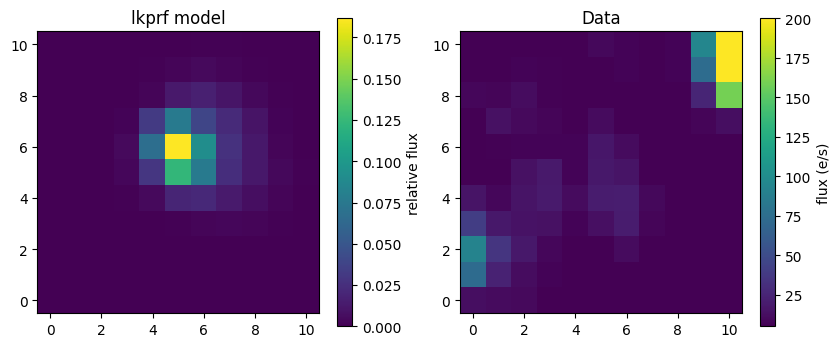

In [95]:
fig,axs = plt.subplots(1,2,figsize=(10,4))

model = axs[0].imshow(prf_mod_faint[0,:,:], origin='lower')
axs[0].set_title('lkprf model')
fig.colorbar(model, ax = axs[0], label='relative flux')

# Plot the real data. We randomly select the 100th observation from the TPF data cube
data = axs[1].imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:], vmin=5, vmax=200, origin='lower')
axs[1].set_title('Data')
fig.colorbar(data, ax = axs[1], label = 'flux (e/s)')

plt.show()

Now lets compute our apertures.

In [96]:
myap_faint = aper(model_prf=prf_mod_faint,tess_mag=TESS_mags_faint,target_index=0)
simple_ap_faint = myap_faint.simple_aperture(completeness=0.9)
strict_ap_faint = myap_faint.strict_aperture()
crowded_ap_faint = myap_faint.crowded_aperture(crowding_metric = 0.8, fluxfrac_metric = 0.9)

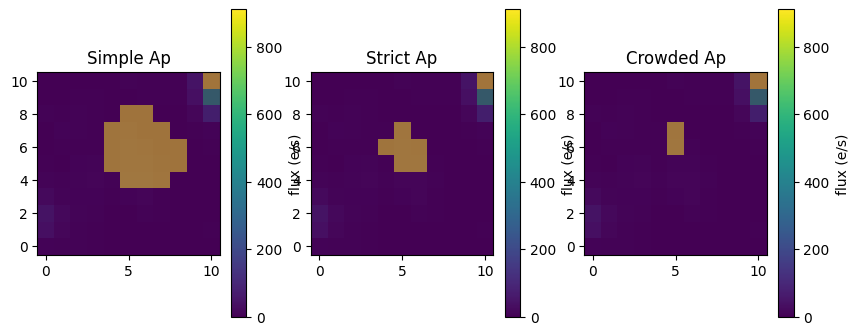

In [97]:
fig,axs = plt.subplots(1,3,figsize=(10,4))

data = axs[0].imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:],  origin='lower')
axs[0].imshow(simple_ap_faint, alpha=0.5, origin='lower')
axs[0].set_title('Simple Ap')
fig.colorbar(data, ax = axs[0], label = 'flux (e/s)')

data = axs[1].imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:],  origin='lower')
axs[1].imshow(strict_ap_faint, alpha=0.5, origin='lower')
axs[1].set_title('Strict Ap')
fig.colorbar(data, ax = axs[1], label = 'flux (e/s)')

data = axs[2].imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:],  origin='lower')
axs[2].imshow(crowded_ap_faint, alpha=0.5, origin='lower')
axs[2].set_title('Crowded Ap')
fig.colorbar(data, ax = axs[2], label = 'flux (e/s)')

plt.show()

We can see here that the crowded aperture is probably the best one here as we want to reduce contamination while maximizing flux contained.